In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df=pd.read_pickle(f"../df.pkl")
y=df[['dm']]
X=df.drop(columns=['dm'])

In [2]:
X.min()

sex              1.000000
age             20.000000
edu              1.000000
income           1.000000
job              1.000000
glu             47.000000
hba1c            3.300000
hdl             16.000000
tg              18.000000
ldl             17.000000
sbp             76.500000
wc              51.100000
bmi             12.461876
wk_smk           0.000000
wk_alc           0.000000
wk_mvpa_play     0.000000
wk_walk          0.000000
wk_sleep        60.000000
stress           1.000000
wk_break         0.000000
wk_lunch         0.000000
wk_dinner        0.000000
wk_veg1          0.000000
wk_veg2          0.000000
wk_fruit         0.000000
dtype: float64

In [3]:
X.max()

sex                2.000000
age               80.000000
edu                4.000000
income             5.000000
job                7.000000
glu              377.000000
hba1c             14.000000
hdl              142.000000
tg              1816.000000
ldl              394.000000
sbp              237.500000
wc               138.500000
bmi               48.054904
wk_smk           420.000000
wk_alc            40.000000
wk_mvpa_play    1680.000000
wk_walk         3780.000000
wk_sleep        1260.000000
stress             4.000000
wk_break           6.000000
wk_lunch           6.000000
wk_dinner          6.000000
wk_veg1           21.000000
wk_veg2           21.000000
wk_fruit          21.000000
dtype: float64

In [4]:
X.shape

(13796, 25)

In [5]:
y.value_counts()

dm
0     7222
1     4471
2     2103
Name: count, dtype: int64

In [6]:
group_col = "dm"

continuous_vars = [
    "age",
    "glu",
    "hba1c",
    "bmi",
    "wc",
    "sbp",
    "ldl",
    "hdl",
    "tg",
    "wk_alc",
    "wk_smk",
    "wk_mvpa_play",
    "wk_walk",
    "wk_sleep",
    "wk_break",
    "wk_lunch",
    "wk_dinner",
    "wk_veg1",
    "wk_veg2",
    "wk_fruit"
]

categorical_vars = [
    "sex",
    "income",
    "edu",
    "job",
    "stress"
]

# 변수명 표시용
var_labels = {
    "age": "Age, years",
    "glu": "FPG",
    "hba1c": "HbA1c",
    "bmi": "Body mass index, kg/m2",
    "wc": "Waist circumference, cm",
    "sbp": "Systolic blood pressure",
    "ldl": "LDL-cholesterol, mg/dL",
    "hdl": "HDL-cholesterol, mg/dL",
    "tg": "Triglycerides, mg/dL",
    "wk_alc": "Weekly alcohol consumption",
    "wk_smk": "Weekly smoking frequency",
    "wk_mvpa_play": "Weekly moderate-to-vigorous physical activity (min)",
    "wk_walk": "Weekly walking time (min)",
    "wk_sleep": "Average daily sleep duration (minutes)",
    "wk_break": "Weekly frequency of breakfast",
    "wk_lunch": "Weekly frequency of lunch",
    "wk_dinner": "Weekly frequency of dinner",
    "wk_veg2": "Weekly consumption of vegetables, mushrooms, and seaweed (excluding kimchi and pickled vegetables)",
    "wk_veg1": "Weekly consumption of vegetables, mushrooms, and seaweed (including kimchi and pickled vegetables)",
    "wk_fruit": "Weekly fruit consumption",
    "sex": "Sex",
    "income": "Household income",
    "edu": "Education level",
    "job": "Occupation",
    "stress": "Self-reported stress level"
}

category_labels = {
    "sex": {
        1: "Male",
        2: "Female"
    },
    "income": {
        1: "1st quartile (lowest)",
        2: "2nd quartile",
        3: "3rd quartile",
        4: "4th quartile",
        5: "5th quartile (highest)"
    },
    "edu": {
        1: "Elementary school or below",
        2: "Middle school",
        3: "High school",
        4: "College or above"
    },
    "job": {
        1: "Managers, professionals, and related occupations",
        2: "Clerical workers",
        3: "Service and sales workers",
        4: "Skilled agricultural, forestry, and fishery workers",
        5: "Craft and machine operators/assemblers",
        6: "Elementary occupations",
        7: "Unemployed (including homemakers and students)"
    },
    "stress": {
        1: "Very high",
        2: "High",
        3: "Moderate",
        4: "Low"
    }
}

group_labels = {
    0: "Normoglycemia",
    1: "Prediabetes",
    2: "Diabetes"
}

# =========================
# 2. Table 1 생성 함수
# =========================

def make_table1(df, group_col, continuous_vars, categorical_vars):
    groups = sorted(df[group_col].dropna().unique())
    group_names = [group_labels.get(g, str(g)) for g in groups]

    rows = []

    # Participants
    row = {"Variable": "Participants, n"}
    for g, gname in zip(groups, group_names):
        row[gname] = f"{(df[group_col] == g).sum()}"
    rows.append(row)

    # Continuous variables
    for var in continuous_vars:
        row = {"Variable": f"{var_labels.get(var, var)}, mean (SD)"}

        for g, gname in zip(groups, group_names):
            x = pd.to_numeric(df.loc[df[group_col] == g, var], errors="coerce")
            mean = x.mean()
            sd = x.std()

            if pd.isna(mean):
                row[gname] = ""
            else:
                row[gname] = f"{mean:.2f} ({sd:.2f})"

        rows.append(row)

    # Categorical variables
    for var in categorical_vars:
        rows.append({"Variable": var_labels.get(var, var)})

        label_map = category_labels.get(var, {})
        categories = list(label_map.keys())

        for cat in categories:
            row = {"Variable": f"  {label_map[cat]}"}

            for g, gname in zip(groups, group_names):
                subset = df[df[group_col] == g]
                denom = subset[var].notna().sum()
                n = (subset[var] == cat).sum()
                pct = n / denom * 100 if denom > 0 else np.nan

                row[gname] = f"{n} ({pct:.1f})" if denom > 0 else ""

            rows.append(row)

    table1 = pd.DataFrame(rows)
    return table1

# =========================
# 3. 실행
# =========================

table1 = make_table1(
    df=df,
    group_col=group_col,
    continuous_vars=continuous_vars,
    categorical_vars=categorical_vars
)

table1

,Variable,Normoglycemia,Prediabetes,Diabetes
0,"Participants, n",7222,4471,2103
1,"Age, years, mean (SD)",46.75 (16.54),58.88 (13.75),64.02 (11.42)
2,"FPG, mean (SD)",90.04 (5.74),103.28 (8.30),132.95 (36.37)
3,"HbA1c, mean (SD)",5.24 (0.24),5.68 (0.32),6.86 (1.13)
4,"Body mass index, kg/m2, mean (SD)",23.21 (3.55),24.96 (3.70),25.44 (3.84)
5,"Waist circumference, cm, mean (SD)",80.18 (10.38),86.77 (9.98),89.89 (9.85)
6,"Systolic blood pressure, mean (SD)",115.46 (14.61),123.49 (15.55),125.93 (15.95)
7,"LDL-cholesterol, mg/dL, mean (SD)",117.99 (33.48),117.42 (38.66),92.72 (38.46)
8,"HDL-cholesterol, mg/dL, mean (SD)",60.97 (15.82),55.74 (14.86),51.47 (13.30)
9,"Triglycerides, mg/dL, mean (SD)",110.39 (80.59),139.44 (97.65),146.10 (107.77)


In [5]:
import torch.cuda
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

True
NVIDIA GeForce RTX 4070 SUPER


In [7]:
import torch.nn as nn
import torch
from lightning.pytorch import LightningModule
from sklearn.metrics import classification_report, confusion_matrix


class MLPModel(nn.Module):
    def __init__(self,input_dim,inter_dim,dropout):
        super().__init__()
        #dim1=int(dim1)
        self.input_layer=nn.Sequential(
            nn.Linear(input_dim,64),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(64,32),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(32,16),
            nn.GELU(),
            nn.Dropout(dropout),            
        )
        self.output_layer=nn.Linear(16,inter_dim)

    def forward(self,x):
        x=self.input_layer(x)
        output=self.output_layer(x)
        return output


class LitModel(LightningModule):
    def __init__(self,  lr=1e-3,do=0.4, wd=1e-4):
        super().__init__()
        #dim1=int(dim1)
        self.save_hyperparameters()
        self.model = MLPModel(25,3,dropout=do)
        self.lr = lr
        self.wd=wd
        
        self.train_acc = []
        self.train_loss=[]
        self.valid_acc = []
        self.valid_loss=[]
        

    def forward(self, x):
        return self.model(x)
    
    def custom_loss(self,preds,targets):
        loss=nn.CrossEntropyLoss()        #HuberLoss: MSELoss, MAELoss의 단점을 보완하고 절충한 손실함수이다.
        final_loss=loss(preds,targets)
        return final_loss

    def training_step(self, batch,batch_idx):
        x, y = batch
        logits = self(x)    #forward 메서드 호출
        loss = self.custom_loss(logits, y.long())
        acc = (logits.argmax(dim=1) == y).float().mean()
        self.log("train_loss", loss, on_epoch=True, on_step=False, prog_bar=True)
        self.log("train_acc", acc, on_epoch=True, on_step=False, prog_bar=True)
        return {"loss": loss, "train_acc": acc}

    def validation_step(self, batch,batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.custom_loss(logits, y.long())
        acc = (logits.argmax(dim=1) == y).float().mean()
        self.log("val_loss", loss, on_epoch=True, on_step=False, prog_bar=True)
        self.log("val_acc", acc, on_epoch=True, on_step=False, prog_bar=True)
        return {"val_loss": loss, "val_acc": acc}

    def test_step(self, batch,batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.custom_loss(logits, y.long())
        acc = (logits.argmax(dim=1) == y).float().mean()
        self.log("test_loss", loss, on_epoch=True, on_step=False, prog_bar=True)
        self.log("test_acc", acc, on_epoch=True, on_step=False, prog_bar=True)
        self.y_preds.append(logits.argmax(dim=1).detach().cpu())
        self.y_trues.append(y.detach().cpu())
        return {"test_loss": loss, "test_acc": acc}

    def configure_optimizers(self):
        optimizer= torch.optim.AdamW(self.parameters(), lr=self.lr, weight_decay=self.wd)
        return optimizer
        
    def predict_step(self, batch, batch_idx):
        x, _ = batch  # 정답(y)는 필요 없으므로 무시
        logits = self.forward(x)           # 예측 (logits)
        preds = torch.argmax(logits, dim=1)  # 가장 높은 점수의 클래스 선택

        return preds  # shape: [B]
    
    def predict_proba(self, x):
        """x: tensor of shape [B, features]"""
        self.eval()
        with torch.no_grad():
            logits = self.model(x)           # (B, 3)
            probs = torch.softmax(logits, dim=1)
        return probs

        

    def on_test_start(self):       #테스트 시작 시 한번만 실행
        self.y_preds = []
        self.y_trues = []

    def on_test_end(self):               #테스트 종료 시 한번만 실행
        preds = torch.cat(self.y_preds)     
        trues = torch.cat(self.y_trues)
        print("\nTest Report:")
        print(classification_report(trues, preds))
        print("Confusion Matrix:")
        print(confusion_matrix(trues, preds))
        

In [8]:
import torch
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader,Subset
from lightning.pytorch import LightningModule,Trainer
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
from lightning.pytorch.loggers import CSVLogger
import ray
import os

from ray import tune
from ray.tune import RunConfig
from ray.tune import TuneConfig
from ray.air import session
from ray.tune.search.hyperopt import HyperOptSearch
from hyperopt import hp
import math


def to_tensor(*dfs):
    return [torch.tensor(df.values,dtype=torch.float32) for df in dfs]

kfold = KFold(n_splits=5, shuffle=True, random_state=42)
acc_results = []
prec_results=[]
rec_results=[]
f1_results=[]

# Windows 환경에서 Ray dashboard 오류 방지
os.environ["RAY_DISABLE_DASHBOARD"] = "1"
os.environ["RAY_LOG_TO_STDERR"] = "1"

X_train, X_test, y_train, y_test = train_test_split(
            X, y,
            test_size=0.2,
            random_state=42,
            shuffle=True
        )


def main():        
        
    model_paths=[]
    scalers=[]
    for fold, (train_idx, val_idx) in enumerate(kfold.split(X_train)):
            
            print(f"\n Inner fold {fold + 1}")
            # Fold 별 subset 구성

            def make_trainable(train_subset, val_subset):
                def trainable(config):
                    train_loader = DataLoader(train_subset, batch_size=int(config["batchsize"]), shuffle=True)
                    val_loader = DataLoader(val_subset, batch_size=int(config["batchsize"]))
                    model = LitModel(lr=config["lr"],wd=config["wd"],do=config["do"])

                    ckpt_base_dir = "./ray_logs/checkpoints"
                    os.makedirs(ckpt_base_dir, exist_ok=True)
                    early_stop = EarlyStopping(monitor="val_acc", patience=100, mode="max")
                    checkpoint = ModelCheckpoint(monitor="val_acc", save_top_k=1, mode="max",dirpath=f"checkpoints/fold_{fold}", filename="best-checkpoint")

                    os.makedirs("./ray_logs", exist_ok=True)
                    log_base_dir = "./ray_logs/tune_logs"

                    os.makedirs(log_base_dir, exist_ok=True)

                    logger = CSVLogger(
                        save_dir="./ray_logs",  # 존재하는 경로로 지정
                        name="tune_logs",       # 폴더 이름
                        version=None            # 자동 버전 생성
                    )

                    trainer = Trainer(
                        accelerator="gpu",
                        devices=1,
                        max_epochs=400,
                        callbacks=[early_stop, checkpoint],
                        logger=logger,
                        enable_progress_bar=True
                        )

                    trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)
                    val_loss = trainer.callback_metrics.get("val_loss")
                    val_acc = trainer.callback_metrics.get("val_acc") 

                    if val_loss and val_acc is not None:
                        session.report({"val_loss": val_loss.item(),"val_acc":val_acc.item()})
                    else:
                        print("no saved values")
                return trainable
            
            X_tr_fold = X_train.iloc[train_idx]
            X_val_fold = X_train.iloc[val_idx]

            scaler = StandardScaler()
            X_tr_fold = scaler.fit_transform(X_tr_fold)
            X_val_fold = scaler.transform(X_val_fold)

            X_tr_fold = torch.tensor(X_tr_fold, dtype=torch.float32)
            X_val_fold = torch.tensor(X_val_fold, dtype=torch.float32)

            y_tr_fold = torch.tensor(
                y_train.iloc[train_idx].values.squeeze(),
                dtype=torch.long
            )

            y_val_fold = torch.tensor(
                y_train.iloc[val_idx].values.squeeze(),
                dtype=torch.long
            )

            train_subset = TensorDataset(X_tr_fold, y_tr_fold)
            val_subset = TensorDataset(X_val_fold, y_val_fold)


            tune_trainable=make_trainable(train_subset=train_subset,val_subset=val_subset)
            tune_trainable = tune.with_resources(tune_trainable, resources={"cpu": 14, "gpu": 1})
            # Ray Tune 실행
            param_space = {"lr": hp.loguniform("lr",-9.21, -4.61),"batchsize":hp.quniform("batchsize",32,256,1),"wd": hp.loguniform("wd",math.log(1e-6), math.log(1e-2)), "do":hp.loguniform("do",math.log(0.2), math.log(0.9))}

            hyperopt = HyperOptSearch(metric="val_acc", mode="max",space=param_space)
            def custom_trial_name(trial):
                return f"trial_{trial.trial_id}"

            tuner = tune.Tuner(
                    trainable=tune_trainable,
                    
                    tune_config=TuneConfig(
                        metric="val_acc",
                        mode="max",
                        num_samples=20, #default=30
                        search_alg=hyperopt,
                        trial_name_creator=custom_trial_name
                    ),
                    run_config=RunConfig(
                        name="hp_tuning",
                        storage_path="C:/ray_tmp",
                        log_to_file=False
                    )
                )

            results = tuner.fit()

                # 결과 출력 및 실패 trial 확인
            
            for i, result in enumerate(results):
                    print(f"\nTrial {i}")
                    if result.error:
                        print("Error:", result.error)
                    else:
                        print("acc:", result.metrics.get("val_acc"))   

            print("\n Best config:", results.get_best_result().config)

            #results에서 얻은 최적 하이퍼파라미터 이용 -> 모델 로드하기 
            best_config=results.get_best_result().config

            best_lr=best_config['lr']
            best_batch =int(best_config['batchsize'])
            best_wd=best_config["wd"]
            best_do=best_config["do"]


            #2. 최적 하이퍼파라미터 적용 모델에 대해 최적 파라미터 탐색
            # 모델 초기화
            train_loader = DataLoader(train_subset, batch_size=best_batch, shuffle=True)
            val_loader = DataLoader(val_subset, batch_size=best_batch)
            model = LitModel(lr=best_lr,wd=best_wd,do=best_do).to(device)
            
            #콜백 정의
            early_stop=EarlyStopping(monitor="val_acc",patience=100,mode="max")
            checkpoint=ModelCheckpoint(monitor="val_acc",mode="max",save_top_k=1,dirpath=f"final_checkpoints/fold_{fold}",filename="best-checkpoint")

            csv_logger = CSVLogger(save_dir="logs/", name="my_model",version=f"fold_{fold}")

            # Trainer 설정 (로그 저장 생략)
            trainer = Trainer(max_epochs=200, min_epochs=5,log_every_n_steps=1, callbacks=[early_stop,checkpoint],logger=csv_logger)
            trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)

            best_model_path=checkpoint.best_model_path
            model_paths.append(best_model_path)
            scalers.append(scaler)

            #test 단계 추가
    
    return model_paths, scalers
    
if __name__ == "__main__":
    
    ray.shutdown()
    RAY_TMP_DIR = "C:\\temp\\ray_tmp" 
    os.makedirs(RAY_TMP_DIR, exist_ok=True)
    ray.init(_temp_dir=RAY_TMP_DIR,include_dashboard=False, logging_config=None)
    model_paths, scalers=main()

2026-07-04 01:35:53,897	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to 'C:/ray_tmp/hp_tuning' in 0.0285s.
2026-07-04 01:35:53,902	INFO tune.py:1041 -- Total run time: 1253.91 seconds (1253.86 seconds for the tuning loop).
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
c:\Users\cmc\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\fabric\loggers\csv_logs.py:268: Experiment logs directory logs/my_model\fold_4 exists and is not empty. Previous log files in this directory will be deleted when the new ones are saved!
c:\Users\cmc\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\callbacks\model_checkpoint.py:658: Checkpoint directory C:\Users\cmc\Desktop\T2D_AI_research\model\final_checkpoints\fold_4 exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name  | Type     | Params | Mode 
---------------------------------


Trial 0
acc: 0.9601268768310547

Trial 1
acc: 0.9614861607551575

Trial 2
acc: 0.8640689253807068

Trial 3
acc: 0.9610331058502197

Trial 4
acc: 0.9637516736984253

Trial 5
acc: 0.9623923897743225

Trial 6
acc: 0.9578613638877869

Trial 7
acc: 0.9605799913406372

Trial 8
acc: 0.9605799913406372

Trial 9
acc: 0.9524241089820862

Trial 10
acc: 0.9614861607551575

Trial 11
acc: 0.9587675333023071

Trial 12
acc: 0.9528772234916687

Trial 13
acc: 0.9614861607551575

Trial 14
acc: 0.9583144783973694

Trial 15
acc: 0.9669234156608582

Trial 16
acc: 0.9642047882080078

Trial 17
acc: 0.9569551348686218

Trial 18
acc: 0.9642047882080078

Trial 19
acc: 0.9623923897743225

 Best config: {'batchsize': 178.0, 'do': 0.3788404462407107, 'lr': 0.00019174558035085776, 'wd': 7.432262143433709e-05}
                                                                            

c:\Users\cmc\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.
c:\Users\cmc\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.


Epoch 199: 100%|██████████| 50/50 [00:00<00:00, 133.51it/s, v_num=ld_4, val_loss=0.147, val_acc=0.949, train_loss=0.199, train_acc=0.929]

`Trainer.fit` stopped: `max_epochs=200` reached.


Epoch 199: 100%|██████████| 50/50 [00:00<00:00, 132.10it/s, v_num=ld_4, val_loss=0.147, val_acc=0.949, train_loss=0.199, train_acc=0.929]


In [9]:
from sklearn.metrics import roc_auc_score

all_probs = []

for model_path, scaler in zip(model_paths, scalers):

    # 1. 모델 로드
    model = LitModel.load_from_checkpoint(model_path)
    model.to(device)
    model.eval()

    # 2. test scaling
    X_test_scaled = scaler.transform(X_test)

    # 3. tensor 변환
    X_test_tensor = torch.tensor(
        X_test_scaled,
        dtype=torch.float32
    ).to(device)

    # 4. prediction
    with torch.no_grad():

        logits = model(X_test_tensor)

        # softmax probability
        probs = torch.softmax(logits, dim=1)

        probs = probs.cpu().numpy()

    all_probs.append(probs)

# =========================
# 평균 probability
# =========================

mean_probs = np.mean(all_probs, axis=0)

# 최종 prediction
y_pred = np.argmax(mean_probs, axis=1)

# =========================
# metric 계산
# =========================

y_true = y_test.values.squeeze()

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average="weighted")
rec = recall_score(y_true, y_pred, average="weighted")
f1 = f1_score(y_true, y_pred, average="weighted")

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 score : {f1:.4f}")


Accuracy : 0.9493
Precision: 0.9493
Recall   : 0.9493
F1 score : 0.9480


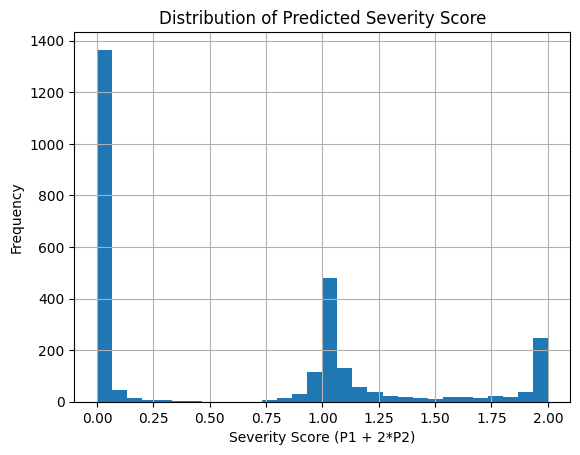

In [10]:
import matplotlib.pyplot as plt

y_score = mean_probs[:, 1] + 2 * mean_probs[:, 2]
y_score_series = pd.Series(y_score)

y_score_series.hist(bins=30)
plt.xlabel("Severity Score (P1 + 2*P2)")
plt.ylabel("Frequency")
plt.title("Distribution of Predicted Severity Score")
plt.show()

In [11]:
import pickle

with open("../model_paths.pkl", "wb") as f:
    pickle.dump(model_paths, f)

with open("../scalers.pkl", "wb") as f:
    pickle.dump(scalers, f)